Kai Gandingco (kcg2279) <br>
COE 311K <br>
Due 30 April 2026 <br>

# Final Project: Part 1

## Section 1: Introduction & Model Selection
For my real world system, I chose to model the population dynamics of harbor seals (*Phoca vitulina*) on or near Sable Island, an island along the Atlantic coast of Canada. These seals follow population dynamics common in predator-prey systems because, although they are protected from hunting by law, they are preyed upon by the stable population of local sharks, and they frequently compete with local grey seals, who are similarly protected, for resources [1]. This naturally results in a carrying capacity and means that their population dynamics can be represented by the governing, second-order ODE of *$$\frac{d^2P}{dt^2} = rP - kP^2$$* <br>where $P$ is the population size, $r$ is the intrinsic growth rate, and $k$ is the carrying capacity factor, also known as the density-dependent competition coefficient. The carrying capacity, $K$, is found by dividing the growth rate by the carrying capacity factor ($\frac{r}{k}$). Converting into a system of first-order ODEs gives the system $$\frac{dP}{dt} = V$$<br>$$\frac{dV}{dt} = rP - kP^2$$<br>where $P$ is the population size and $V$ is the instantaneous growth rate.

## Section 2: Parameter Research & Justification
While researching the harbor seals on Sable Island, I specifically decided to model their population dynamics in the late 20th century, from 1970 to 2000. This was a significant era for harbor seals because this marked the beginning of their protection from hunting, as part of Canada's broader conservation efforts regarding marine mammals [2]. Understanding this, I opted for an initial population size, or initial condition, of 100 seals, in order to represent the harbor seals as a small, recovering population. This serves as the foundation for the parameters I set, and this number is particularly realistic given the recorded harbor seal births on Sable Island during this era [3] and the estimate that pups make up about 15% to 20% of harbor seal populations (after initial infant mortality) [4]. Further research also showed a peak number of pups born in 1989, with 625 harbor seal pups born that year [3]. Following this peak, births declined significantly.
<br><br>
### List of Parameters
I couldn't figure out how to format a table in a Markdown cell, so a list of all parameters is as follows:<br><br>
Population size, $P(t)$: measured in seals<br>
Initial population size, $P(0)$: 100 seals [2, 3]<br>
Instantaneous growth rate, $\frac{dP}{dt}$ or $V(t)$: measured in seals per year<br>
Initial instantaneous growth rate, $V(0)$: 15.5 seals per year [4]<br>
Intrinsic growth rate (of the population, regardless of population size), $r$: 0.16 per year [2, 3]<br>
Carrying capacity factor, $k$: 5.1 x $10^{-5}$ [3, 4]<br>
Carrying capacity, $K$: 3137 seals

In [9]:
# Section 3: Numerical Methods Implementation

import numpy as np
import matplotlib.pyplot as plt

# Parameter definitions
startYear, endYear = 0, 30 # 1970 to 2000
P0 = 100 # initial population size
V0 = 15.5 # initial instantaneous growth rate
y0 = np.array([P0, V0])
r = 0.16 # intrinsic growth rate
k = 5.1e-5 # carrying capacity factor

# ODE definition
def f(t, y):
    P, V = y # vector y consists of population size and instantaneous growth rate
    dP_dt = V # change in population over change in time
    dV_dt = r*P - k*P**2 # change in instantaneous growth rate over time
    return np.array([dP_dt, dV_dt])

In [10]:
# Euler's Forward Method

def euler_forward(f, h, y0, startYear, endYear):
    allTimes = np.arange(startYear, endYear + h, h) # creates time intervals from 1970 to 2000
    solutions = np.zeros((len(allTimes), len(y0))) # stores estimates (solutions)
    solutions[0] = y0
    
    for i in range(len(allTimes)-1):
        solutions[i+1] = solutions[i] + h * f(allTimes[i], solutions[i])
        # current slope estimates next point, which gets stored in solutions
        
    return allTimes, solutions

In [11]:
# RK4 Method

def rk4(f, h, y0, startYear, endYear):
    allTimes = np.arange(startYear, endYear + h, h) # creates time intervals from 1970 to 2000
    solutions = np.zeros((len(allTimes), len(y0))) # stores estimates (solutions)
    solutions[0] = y0
    
    for i in range(len(allTimes)-1):
        t = allTimes[i]
        y = solutions[i]
        
        k1 = f(t, y) # slope at the beginning of the interval
        k2 = f(t + h/2, y + h/2 * k1) # slope in the middle of the interval
        k3 = f(t + h/2, y + h/2 * k2) # second slope in the middle of the interval
        k4 = f(t + h, y + h * k3) # slope at the end of the interval
        
        solutions[i+1] = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        
    return allTimes, solutions

## Section 3: Numerical Methods Implementation
In order to solve and plot the model, the harbor seal population model was converted from a second-order differential equation into a system of two first-order differential equations. This system was then solved using Euler's Forward Method and the Fourth-Order Runge Kutta (RK4) Method. Euler's Forward Method calculates the slope at the current point, then extrapolates along that line to estimate the next value. Similarly, the RK4 Method estimates the next value by taking the weighted average of four slope estimates within a step size interval. Both of these methods were implemented as functions that iteratively advance the solution using fixed step sizes. These functions were used to simulate the model over the interval of 1970 to 2000, using three different step sizes to compare accuracy and stability.

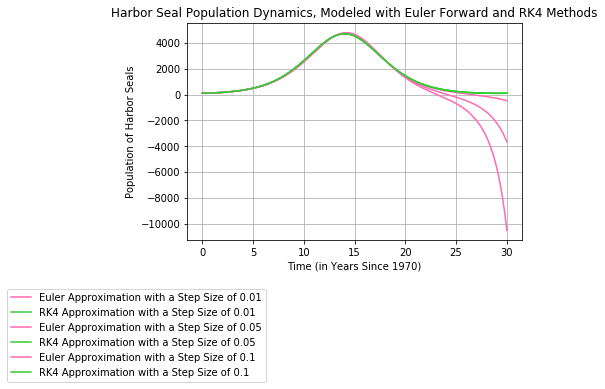

In [17]:
# Section 4: Solutions & Comparison

# Population vs. Time

step_sizes = [0.01, 0.05, 0.1]

plt.figure()

for h in step_sizes:
    euler_times, euler_solutions = euler_forward(f, h, y0, startYear, endYear)
    rk4_times, rk4_solutions = rk4(f, h, y0, startYear, endYear)
    
    # Plotting
    plt.plot(euler_times, euler_solutions[:,0], color='hotpink', label=f'Euler Approximation with a Step Size of {h}')
    plt.plot(rk4_times, rk4_solutions[:,0], color='limegreen', label=f'RK4 Approximation with a Step Size of {h}')
    
plt.title("Harbor Seal Population Dynamics, Modeled with Euler Forward and RK4 Methods")
plt.xlabel("Time (in Years Since 1970)")
plt.ylabel("Population of Harbor Seals")
plt.legend(bbox_to_anchor = (0.25, -0.2))
plt.grid()
plt.show()

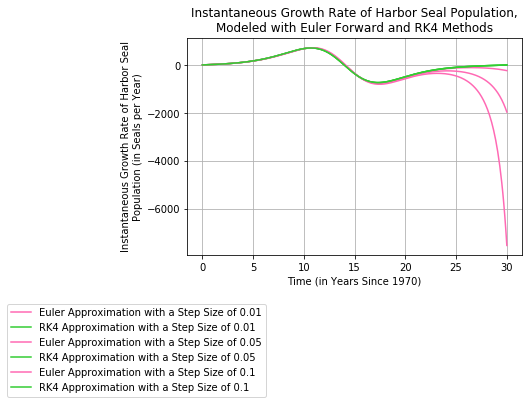

In [18]:
# Instantaneous Growth Rate vs. Time

step_sizes = [0.01, 0.05, 0.1]

plt.figure()

for h in step_sizes:
    euler_times, euler_solutions = euler_forward(f, h, y0, startYear, endYear)
    rk4_times, rk4_solutions = rk4(f, h, y0, startYear, endYear)
    
    # Plotting
    plt.plot(euler_times, euler_solutions[:,1], color='hotpink', label=f'Euler Approximation with a Step Size of {h}')
    plt.plot(rk4_times, rk4_solutions[:,1], color='limegreen', label=f'RK4 Approximation with a Step Size of {h}')
    
plt.title("Instantaneous Growth Rate of Harbor Seal Population,\nModeled with Euler Forward and RK4 Methods")
plt.xlabel("Time (in Years Since 1970)")
plt.ylabel("Instantaneous Growth Rate of Harbor Seal\nPopulation (in Seals per Year)")
plt.legend(bbox_to_anchor = (0.25, -0.2))
plt.grid()
plt.show()

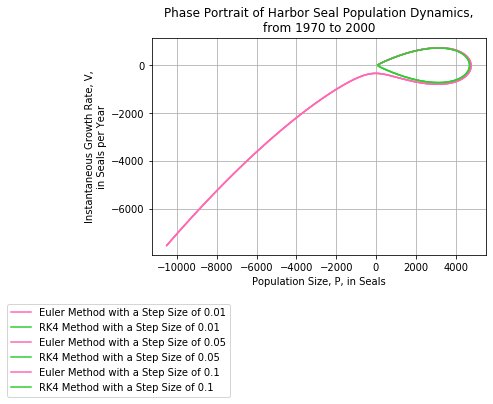

In [19]:
# Phase Portrait
plt.figure()

for h in step_sizes:
    
    plt.plot(euler_solutions[:,0], euler_solutions[:,1], color='hotpink', label=f'Euler Method with a Step Size of {h}')
    plt.plot(rk4_solutions[:,0], rk4_solutions[:,1], color='limegreen', label=f'RK4 Method with a Step Size of {h}')
    
plt.title(f"Phase Portrait of Harbor Seal Population Dynamics,\nfrom 1970 to 2000")
plt.xlabel("Population Size, P, in Seals")
plt.ylabel("Instantaneous Growth Rate, V,\nin Seals per Year")
plt.legend(bbox_to_anchor = (0.25, -0.2))
plt.grid()
plt.show()

## Section 4: Solutions & Comparison
The most striking visual differences between the Euler Forward and RK4 methods begin to occur after the 20 year mark (1990). Past this point, the solution produced by the Euler Forward Method declines dramatically, illustrating clear instability in both the population size plot and the instantaneous growth rate plot. This instability is further demonstrated in the phase portrait, where the pink curve, representing the Euler Forward Method, curves dramatically into a negative population size, unlike the RK4 method. However, a more detailed discussion of stability limits between the two methods is included in the next section.

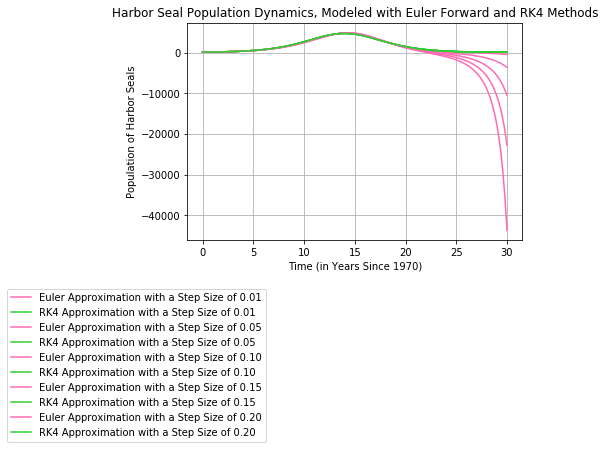

In [20]:
# Section 5: Stability Analysis

# Part A: Step Size Investigation

step_sizes = np.arange(0, 0.25, 0.05)
step_sizes[0] = 0.01

plt.figure()

for h in step_sizes:
    euler_times, euler_solutions = euler_forward(f, h, y0, startYear, endYear)
    rk4_times, rk4_solutions = rk4(f, h, y0, startYear, endYear)
    
    # Plotting
    plt.plot(euler_times, euler_solutions[:,0], color='hotpink', label=f'Euler Approximation with a Step Size of {h:.2f}')
    plt.plot(rk4_times, rk4_solutions[:,0], color='limegreen', label=f'RK4 Approximation with a Step Size of {h:.2f}')
    
plt.title("Harbor Seal Population Dynamics, Modeled with Euler Forward and RK4 Methods")
plt.xlabel("Time (in Years Since 1970)")
plt.ylabel("Population of Harbor Seals")
plt.legend(bbox_to_anchor = (0.25, -0.2))
plt.grid()
plt.show()

## Section 5: Stability Analysis
### Part A: Step Size Investigation
For the Euler Forward Method, the maximum stable step size is 0.01; all larger step sizes that were tested resulted in instability within the 30-year window. In contrast, for the RK4 Method, all step sizes up to 0.2, the largest step size tested, remained stable for the duration of the 30-year period. 

When the step size is too large for the Euler Forward Method, the plot highlights unstable, diverging behavior; the Euler Method curves decline sharply, misrepresenting the population size as negative.

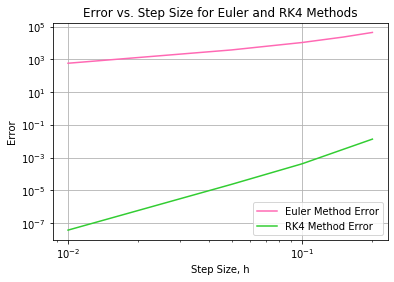

In [21]:
# Part B: Error Quantification

referenced_times, referenced_solutions = rk4(f, 0.001, y0, startYear, endYear)
# RK4 with a very small step size serves as reference solution
euler_error = []
rk4_error = []

def get_error(times, measured, referenced_times, referenced_solutions):
    referenced = np.interp(times, referenced_times, referenced_solutions)
    return np.max(np.abs(measured - referenced))

for h in step_sizes:
    euler_times, euler_solutions = euler_forward(f, h, y0, startYear, endYear)
    euler_error.append(get_error(euler_times, euler_solutions[:,0], referenced_times, referenced_solutions[:,0]))
    rk4_times, rk4_solutions = rk4(f, h, y0, startYear, endYear)
    rk4_error.append(get_error(rk4_times, rk4_solutions[:,0], referenced_times, referenced_solutions[:,0]))
    
# Log-log plot of error vs. step size
plt.figure()
plt.loglog(step_sizes, euler_error, color='hotpink', label='Euler Method Error')
plt.loglog(step_sizes, rk4_error, color='limegreen', label='RK4 Method Error')
plt.title("Error vs. Step Size for Euler and RK4 Methods")
plt.xlabel("Step Size, h")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

### Part B: Error Quantification
In place of an analytical solution, RK4 with a very small step size (h = 0.001) was used as the reference solution. The numerical errors were then computed by comparing each method's population values to the reference solution for the same time intervals. From plotting these errors on a log-log plot, we see how error for both methods increases as step size increases. It is also noteworthy that the RK4 curve is steeper than the Euler Method curve; a steeper slope indicates a higher order of convergence, meaning that as step size is reduced, RK4's error decreases more rapidly than Euler Forward's.

### Part C: Physical Interpretation
When using the Euler Forward Method for this population model, too large of a step size can lead to numerical instability and non-physical results. Namely, for step sizes larger than approximately 0.01, the Euler Forward solutions become unstable after around 1990; this instability manifests in the solutions as negative population sizes, which is an example of non-physical results. In contrast, the RK4 Method illustrates stable behavior that reflects the physical behavior of the harbor seal population. The RK4 curves highlight how the harbor seal population realistically decreases after surpassing its carrying capacity. In the plots, this manifests as the slight parabolic shape formed by the RK4 curves around 1985.

## Section 6: Conclusions
Overall, the Fourth-Order Runge-Kutta (RK4) Method consistently performed better than Euler's Forward Method in modeling harbor seal population dynamics. However, this performance is not without its sacrifices; by evaluating multiple slopes each step, RK4 quickly accumulates a higher computational cost. Nonetheless, I would still recommend using the RK4 Method for similar scenarios, given its accuracy and stability. While Euler's Method naturally involves a lower computational cost, it requires a small step size to maintain stability throughout the time period of interest, which is not ideal for modeling long-term population dynamics. As a whole, this analysis reflects the trade-offs required in computation and how selecting the right numerical method and step size is key to modeling realistic, physically observable outcomes.

## References
#### Using IEEE citation formatting
[1] "Harbour seals." Parks Canada. Jan. 31, 2025. [Online]. Available: https://parks.canada.ca/pn-np/ns/sable/nature/animaux-animals/phoques-communs-harbour-seals [Accessed Apr. 27, 2026].<br>
[2] "Harbour Seal." North Atlantic Marine Mammal Commission. Aug. 2024. [Online]. Available: https://nammco.no/harbour-seal/#1475762140594-0925dd6e-f6cc [Accessed Apr. 27, 2026].<br>
[3] W. D. Bowen and S. L. Ellis. "Maternal and newborn life-history traits during periods of contrasting population trends: Implications for explaining the decline of harbour seals (Phoca vitulina), on Sable Island." Journal of Zoology. Oct. 2003. [Online]. Available: https://www.researchgate.net/publication/200054766_Maternal_and_newborn_life-history_traits_duri]ng_periods_of_contrasting_population_trends_Implications_for_explaining_the_decline_of_harbour_seals_Phoca_vitulina_on_Sable_Island [Accessed Apr. 27, 2026].<br>
[4] "All About the Harbor Seal - Birth & Care of Young." SeaWorld. [Online]. Available: https://seaworld.org/animals/all-about/harbor-seal/care-of-young/ [Accessed Apr. 27, 2026].<br>